In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from dv_score import cast, io, util
from dv_score.cast import C57, CAST, STRAINS
from dv_score.constants import GEP3, GEP3_qt
from dv_score.viz import moe_style_context, viz

In [3]:
sns.set_theme(font_scale=1, style="ticks", palette="tab10", context="talk")
F1_colors = [plt.cm.Set1(1), plt.cm.Set1(0)]
GRAY = "0.7"

# scRNA-seq from CAST x C57 F1 hybrids
* ORs with significant shifts across strains were determined empirically

In [4]:
df_OR_gep = cast.load_files()
is_sig = cast.find_sig_subtypes(df_OR_gep)

sig_dict = {}
for g in GEP3_qt:
    sig_dict[g] = is_sig.index[is_sig[f"{g}_abs"]]

Calculating sig ORs for each GEP with 99 % threshold.


100%|██████████████████████████████████████| 1000/1000 [00:09<00:00, 100.79it/s]


In [5]:
is_sig_mat = is_sig.copy()
is_sig_mat.columns = is_sig_mat.columns.map(lambda l: l.split("_")[0])
sig_melt = (is_sig_mat * 100).melt()

Text(0.5, 1.05, 'F$_1$ hybrid animals')

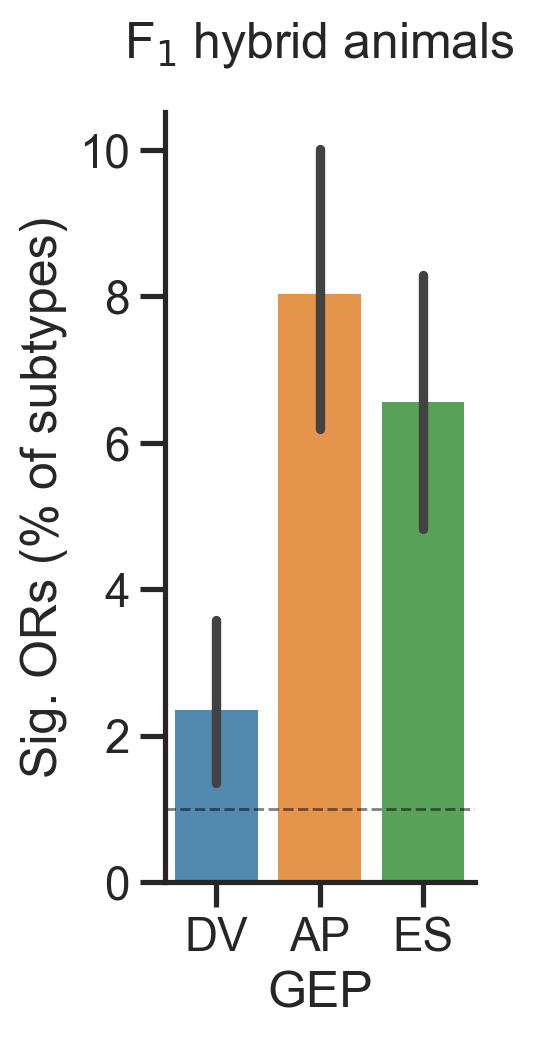

In [6]:
fig, ax = plt.subplots(figsize=(2,5))
sns.barplot(
    data=sig_melt,
    x="variable",
    y="value",
    ax=ax,
    order=GEP3,
    linewidth=0,
    alpha=0.85,
    hue="variable",
    hue_order=GEP3,
    palette="tab10",
    dodge=False,
)
ax.axhline(1, ls="--", color="k", lw=1, alpha=0.5)
sns.despine()
ax.set_ylabel("Sig. ORs (% of subtypes)")
ax.set_xlabel("GEP")
ax.set_title(f"{cast.F1} hybrid animals", y=1.05)

In [7]:
df_subset = df_OR_gep[df_OR_gep.abs_strain_delta >= cast.DELTA_THRESH].copy()
good_olfr, has_enough = util.filter_OR_source_numba(
    df_subset, cast.F1_THRESH, col="strain_max"
)
print(len(good_olfr))

df__keep = df_subset[has_enough].copy()
df__mean = df__keep.groupby(["top_Olfr", "strain"]).mean(numeric_only=True)

809


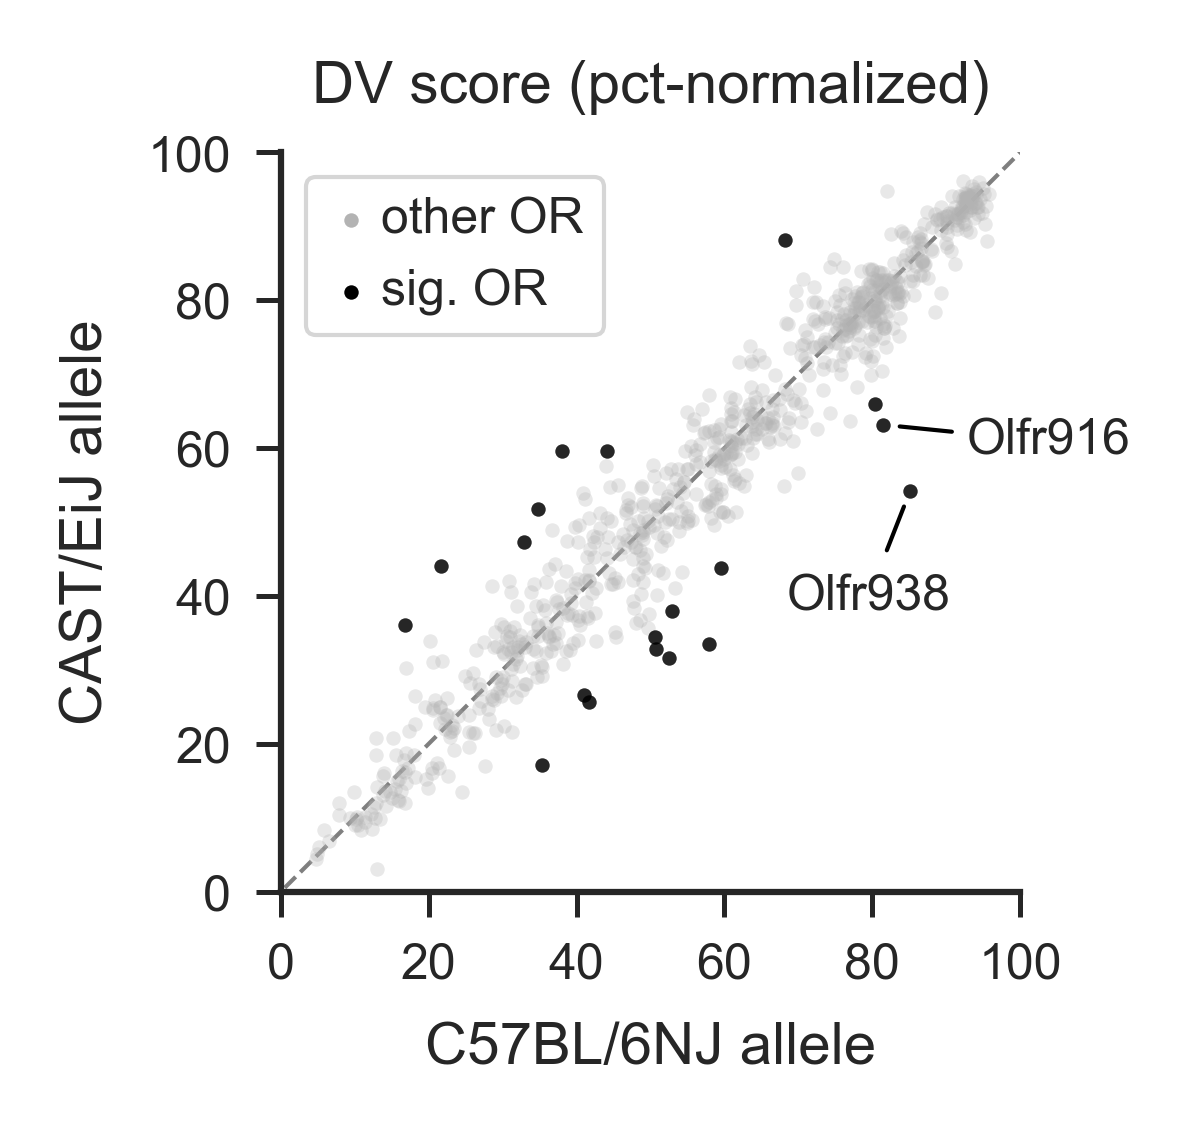

In [8]:
with moe_style_context():
    _df = df__mean["DV_qt"].unstack()
    fig, ax = plt.subplots(figsize=(1.6, 1.6))
    is_sig = _df.index.isin(sig_dict["DV_qt"])
    ax.scatter(
        _df[C57][~is_sig],
        _df[CAST][~is_sig],
        c=GRAY,
        alpha=0.3,
        s=3,
        lw=0,
        label="other OR",
    )
    ax.scatter(
        _df[C57][is_sig],
        _df[CAST][is_sig],
        alpha=0.85,
        lw=0,
        s=3,
        color="k",
        label="sig. OR",
    )
    leg = ax.legend(
        handletextpad=0.1,
        loc="upper left",
        bbox_to_anchor=(0, 1.0),
        frameon=True,
        handlelength=1,
    )
    for lh in leg.legend_handles:
        lh.set_alpha(1)
    leg.get_frame().set_linewidth(0.5)
    ax.set_title("DV score (pct-normalized)")
    ax.set_xlabel(f"{C57} allele")
    ax.set_ylabel(f"{CAST} allele")
    sns.despine()
    viz.adjust_lims(ax, lw=0.5)

    ax.annotate(
        "Olfr938",
        xy=_df.loc["Olfr938"],
        xytext=(-5, -10),
        textcoords="offset points",
        ha="center",
        va="top",
        arrowprops=dict(arrowstyle="-", connectionstyle="arc,rad=0", color="k", lw=0.5),
        bbox={"pad": 1, "facecolor": "None", "ec": "None"},
    )

    ax.annotate(
        "Olfr916",
        xy=_df.loc["Olfr916"],
        xytext=(10, -2),
        textcoords="offset points",
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="-", connectionstyle="arc,rad=0", color="k", lw=0.5),
        bbox={"pad": -0.25, "facecolor": "None", "ec": "None"},
    )
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
    ax.set_box_aspect(1)
    ax.axis("equal")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

## Look at example ORs

In [9]:
df_f0_f1 = cast.load_files(f1_only=False)

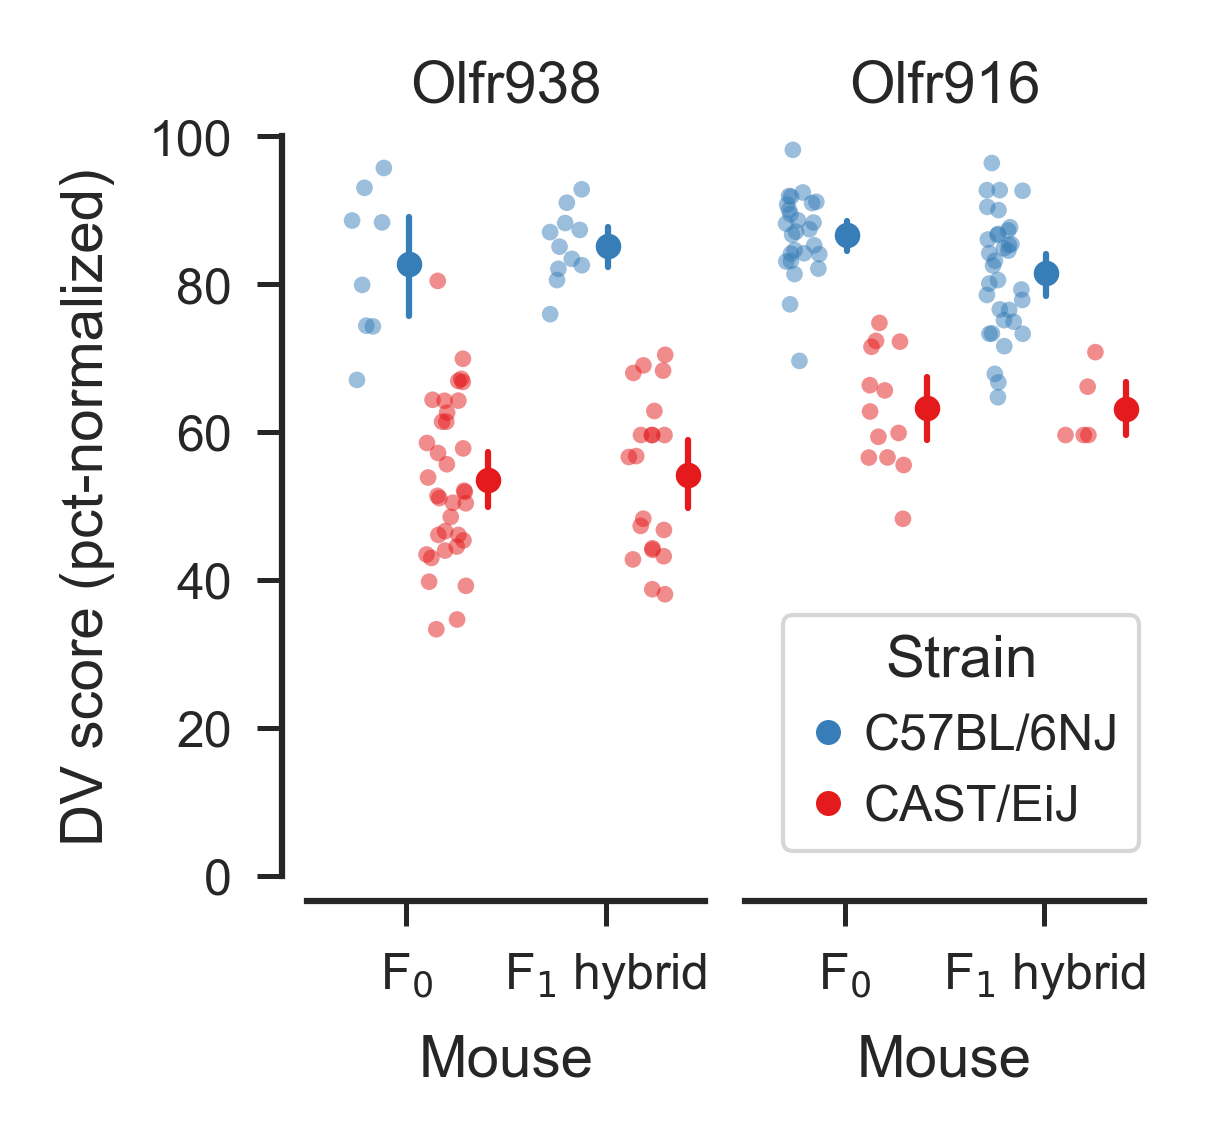

In [10]:
olfrs = ["Olfr938", "Olfr916"]
no = len(olfrs)
np.random.seed(2025)
mouse_gen = df_f0_f1["gen"].unique()

with moe_style_context():
    fig, axes = plt.subplots(1, no, figsize=(no * 0.9, 1.6), sharex=True, sharey=False)
    for ax, olfr in zip(axes, olfrs):
        this_olfr = df_f0_f1[df_f0_f1.top_Olfr == olfr]
        sns.pointplot(
            data=this_olfr,
            x="gen",
            hue="strain",
            y="DV_qt",
            ax=ax,
            hue_order=STRAINS,
            dodge=0.4,
            linestyles="none",
            linewidth=0.75,
            order=mouse_gen,
            palette=F1_colors,
            markersize=2.5,
        )
        viz.offset_pointplot(ax, 0.07)

        sns.stripplot(
            data=this_olfr,
            x="gen",
            hue="strain",
            y="DV_qt",
            dodge=0.4,
            ax=ax,
            hue_order=STRAINS,
            palette=F1_colors,
            alpha=0.5,
            jitter=0.2,
            size=2,
            order=mouse_gen,
        )
        handles, labels = ax.get_legend_handles_labels()
        ax.legend().remove()
        ax.set_title(olfr, y=0.98)
        ax.set_ylabel(None)
        ax.set_ylim(0, 100)
        ax.set_xlabel("Mouse")

    axes[0].set_ylabel("DV score (pct-normalized)")
    plt.subplots_adjust(wspace=0.1)
    leg = axes[1].legend(
        handles[-2:],
        labels[-2:],
        handletextpad=0.2,
        loc="lower right",
        bbox_to_anchor=(1.05, -0.0),
        title="Strain",
        frameon=True,
        handlelength=1,
        ncols=1,
        columnspacing=0.5,
        markerscale=1.5,
    )
    for lh in leg.legend_handles:
        lh.set_alpha(1.0)
    leg.get_frame().set_linewidth(0.5)
    sns.despine(offset=3)
    # fig.supxlabel("Mouse", y=-0.1)

    for ax in axes:
        ax.set_xticks([0, 1])
        ax.set_xticklabels([cast.F0, f"{cast.F1} hybrid"])

    axes[1].set_yticks([])
    axes[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
    axes[1].spines.left.set_visible(False)